### import libraries

In [8]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from XLO_sim import tools

notebook_path = os.path.abspath("__file__")
notebook_directory = os.path.dirname(notebook_path)
base_directory = os.path.dirname(notebook_directory)
figs_path = os.path.join(base_directory, 'figs')
os.makedirs(figs_path, exist_ok=True)

### load simulation (mono sweep) results

Mirrors `plot-mono-transmittance-vs-intensity.ipynb` cell 7 -- point `data_path` at whatever
`run_mono_sweep.py` output folder you want to compare (e.g. `../data/mono_sweep`).

In [9]:
data_path = "../data/mono_sweep_double_satellite"

sorted_accumulated_arrays, aux_data, num_files = tools.data_from_folder(
    data_path, group_keys=('E_seed_uJ', 'monochromator_target_energy_eV'),
    aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3', 'sigma1_Ka1_other',
              'seed_duration_FWHM_t', 'hwKalpha1N'],
)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, hwKalpha1N = aux_data

sim_transmittance = {}
for E_seed_value, energy_arrays in sorted_accumulated_arrays.items():
    energy_values = np.array(sorted(energy_arrays.keys()))
    T_values = np.zeros_like(energy_values)
    for i, energy_value in enumerate(energy_values):
        arrays = energy_arrays[energy_value]
        T_values[i] = np.sum(arrays['I_int_thy_w_last']) / np.sum(arrays['I_int_thy_w_0'])
    sim_transmittance[E_seed_value] = (energy_values, T_values)

sorted(sim_transmittance.keys())

[0.1, 1, 5, 20, 30]

### load experimental data

Hand-digitized from `docs/Results_RSA_seeded.pdf` slide 9 ("Cu 20 um, self-seeded beam") --
see the header comment in the CSV for caveats (approximate, read off the chart by eye, not
a precision reference -- use for dip depth/width comparisons, not point-by-point fitting).

In [10]:
exp_df = pd.read_csv("../data/transmittance_seeded_uJ.csv", comment='#')
exp_energies_uJ = [float(c.split('uJ')[0]) for c in exp_df.columns if c != 'Photon_energy_eV']
exp_df.head()

,Photon_energy_eV,0.1uJ_transmittance,1uJ_transmittance,5uJ_transmittance,10uJ_transmittance,20uJ_transmittance,30uJ_transmittance,40uJ_transmittance,50uJ_transmittance
0,8000,0.410,0.413,0.397,0.404,0.404,0.403,0.400,0.400
1,8005,0.410,0.411,0.406,0.406,0.398,0.390,0.393,0.398
2,8010,0.409,0.408,0.401,0.403,0.394,0.383,0.388,0.383
3,8015,0.408,0.404,0.393,0.390,0.362,0.375,0.362,0.322
4,8020,0.406,0.400,0.390,0.378,0.322,0.310,0.320,0.338


### overlay: simulation vs. experiment, per pulse energy

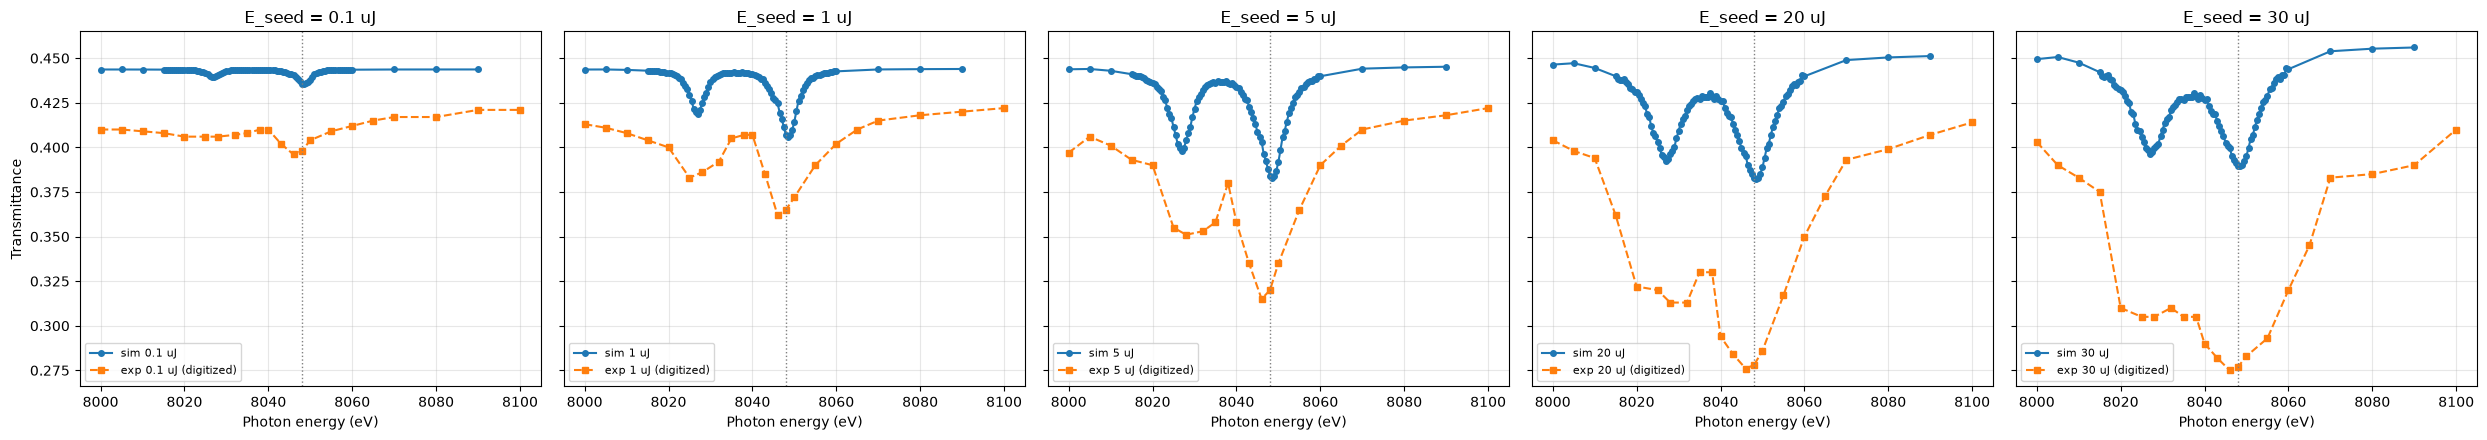

In [11]:
# Match each simulated E_seed to the nearest digitized experimental energy column.
sim_E_values = sorted(sim_transmittance.keys())

fig, axs = plt.subplots(1, len(sim_E_values), figsize=(5 * len(sim_E_values), 4.5), sharey=True)
if len(sim_E_values) == 1:
    axs = [axs]

for ax, E_seed_value in zip(axs, sim_E_values):
    energy_values, T_values = sim_transmittance[E_seed_value]
    ax.plot(energy_values, T_values, 'o-', color='tab:blue', ms=4, label=f'sim {E_seed_value:g} uJ')

    E_exp = min(exp_energies_uJ, key=lambda e: abs(e - E_seed_value))
    ax.plot(exp_df['Photon_energy_eV'], exp_df[f'{E_exp:g}uJ_transmittance'],
            's--', color='tab:orange', ms=4, label=f'exp {E_exp:g} uJ (digitized)')

    ax.axvline(hwKalpha1N, color='grey', ls=':', lw=1)
    ax.set_xlabel('Photon energy (eV)')
    ax.set_title(f'E_seed = {E_seed_value:g} uJ')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axs[0].set_ylabel('Transmittance')
plt.tight_layout()
plt.savefig(os.path.join(figs_path, 'mono_transmittance_sim_vs_experiment.pdf'))
plt.show()

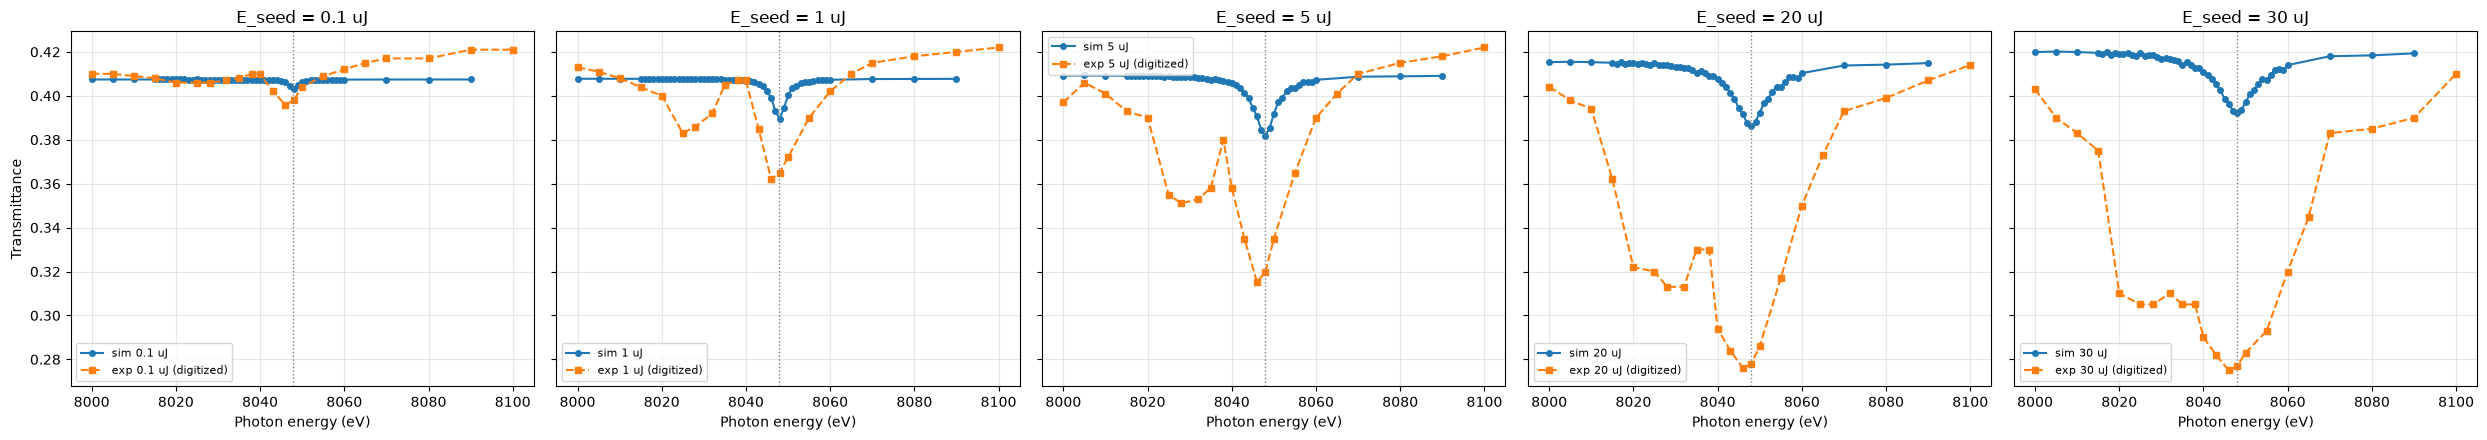

In [12]:
data_path = "../data/production_sweep_mono_24398308/Cu-seed-mono-SASE-original"

sorted_accumulated_arrays, aux_data, num_files = tools.data_from_folder(
    data_path, group_keys=('E_seed_uJ', 'monochromator_target_energy_eV'),
    aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3', 'sigma1_Ka1_other',
              'seed_duration_FWHM_t', 'hwKalpha1N'],
)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, hwKalpha1N = aux_data

sim_transmittance = {}
for E_seed_value, energy_arrays in sorted_accumulated_arrays.items():
    energy_values = np.array(sorted(energy_arrays.keys()))
    T_values = np.zeros_like(energy_values)
    for i, energy_value in enumerate(energy_values):
        arrays = energy_arrays[energy_value]
        T_values[i] = np.sum(arrays['I_int_thy_w_last']) / np.sum(arrays['I_int_thy_w_0'])
    sim_transmittance[E_seed_value] = (energy_values, T_values)

sorted(sim_transmittance.keys())

# Match each simulated E_seed to the nearest digitized experimental energy column.
sim_E_values = sorted(sim_transmittance.keys())

fig, axs = plt.subplots(1, len(sim_E_values), figsize=(5 * len(sim_E_values), 4.5), sharey=True)
if len(sim_E_values) == 1:
    axs = [axs]

for ax, E_seed_value in zip(axs, sim_E_values):
    energy_values, T_values = sim_transmittance[E_seed_value]
    ax.plot(energy_values, T_values, 'o-', color='tab:blue', ms=4, label=f'sim {E_seed_value:g} uJ')

    E_exp = min(exp_energies_uJ, key=lambda e: abs(e - E_seed_value))
    ax.plot(exp_df['Photon_energy_eV'], exp_df[f'{E_exp:g}uJ_transmittance'],
            's--', color='tab:orange', ms=4, label=f'exp {E_exp:g} uJ (digitized)')

    ax.axvline(hwKalpha1N, color='grey', ls=':', lw=1)
    ax.set_xlabel('Photon energy (eV)')
    ax.set_title(f'E_seed = {E_seed_value:g} uJ')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axs[0].set_ylabel('Transmittance')
plt.tight_layout()
plt.savefig(os.path.join(figs_path, 'mono_transmittance_sim_vs_experiment.pdf'))
plt.show()

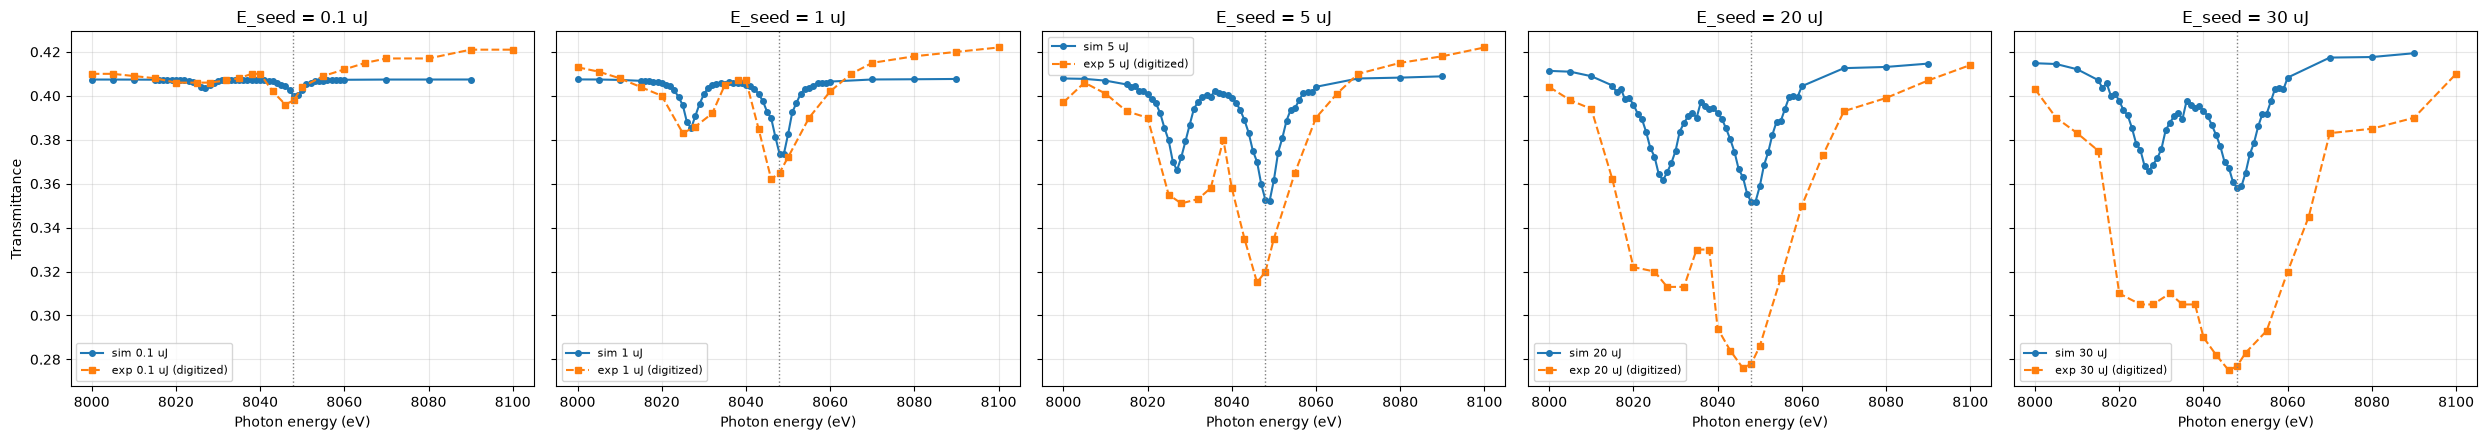

In [13]:
data_path = "../data/production_sweep_mono_24398308/Cu-seed-mono-SASE-double-satellite"

sorted_accumulated_arrays, aux_data, num_files = tools.data_from_folder(
    data_path, group_keys=('E_seed_uJ', 'monochromator_target_energy_eV'),
    aux_keys=['tgrid', 'xgrid', 'ygrid', 'zgrid', 'sigma1_Ka1_2p3', 'sigma1_Ka1_other',
              'seed_duration_FWHM_t', 'hwKalpha1N'],
)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t, hwKalpha1N = aux_data

sim_transmittance = {}
for E_seed_value, energy_arrays in sorted_accumulated_arrays.items():
    energy_values = np.array(sorted(energy_arrays.keys()))
    T_values = np.zeros_like(energy_values)
    for i, energy_value in enumerate(energy_values):
        arrays = energy_arrays[energy_value]
        T_values[i] = np.sum(arrays['I_int_thy_w_last']) / np.sum(arrays['I_int_thy_w_0'])
    sim_transmittance[E_seed_value] = (energy_values, T_values)

sorted(sim_transmittance.keys())

# Match each simulated E_seed to the nearest digitized experimental energy column.
sim_E_values = sorted(sim_transmittance.keys())

fig, axs = plt.subplots(1, len(sim_E_values), figsize=(5 * len(sim_E_values), 4.5), sharey=True)
if len(sim_E_values) == 1:
    axs = [axs]

for ax, E_seed_value in zip(axs, sim_E_values):
    energy_values, T_values = sim_transmittance[E_seed_value]
    ax.plot(energy_values, T_values, 'o-', color='tab:blue', ms=4, label=f'sim {E_seed_value:g} uJ')

    E_exp = min(exp_energies_uJ, key=lambda e: abs(e - E_seed_value))
    ax.plot(exp_df['Photon_energy_eV'], exp_df[f'{E_exp:g}uJ_transmittance'],
            's--', color='tab:orange', ms=4, label=f'exp {E_exp:g} uJ (digitized)')

    ax.axvline(hwKalpha1N, color='grey', ls=':', lw=1)
    ax.set_xlabel('Photon energy (eV)')
    ax.set_title(f'E_seed = {E_seed_value:g} uJ')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axs[0].set_ylabel('Transmittance')
plt.tight_layout()
plt.savefig(os.path.join(figs_path, 'mono_transmittance_sim_vs_experiment.pdf'))
plt.show()

### off-resonance baseline check

Sim vs. experiment far-detuned transmittance (large |E - E_Kalpha1|) isolates the *non-resonant*
photoionization opacity (n * sigma_total * L via `sigma1_Ka1_2s/2p3/other`, thickness `zmax`), with
no RSA/Kalpha physics involved -- if this baseline itself is off, the cross-section/thickness inputs
(not the resonant model) are the first thing to check.

In [14]:
for E_seed_value in sim_E_values:
    energy_values, T_values = sim_transmittance[E_seed_value]
    off_res = np.abs(energy_values - hwKalpha1N) > 25
    sim_baseline = np.mean(T_values[off_res]) if off_res.any() else np.nan

    E_exp = min(exp_energies_uJ, key=lambda e: abs(e - E_seed_value))
    exp_col = exp_df[f'{E_exp:g}uJ_transmittance']
    exp_off_res = np.abs(exp_df['Photon_energy_eV'] - hwKalpha1N) > 25
    exp_baseline = exp_col[exp_off_res].mean()

    print(f"E_seed={E_seed_value:>6g} uJ  sim baseline T={sim_baseline:.3f}   "
          f"exp baseline T={exp_baseline:.3f} (matched to {E_exp:g} uJ)")

E_seed=   0.1 uJ  sim baseline T=0.407   exp baseline T=0.413 (matched to 0.1 uJ)
E_seed=     1 uJ  sim baseline T=0.406   exp baseline T=0.412 (matched to 1 uJ)
E_seed=     5 uJ  sim baseline T=0.404   exp baseline T=0.405 (matched to 5 uJ)
E_seed=    20 uJ  sim baseline T=0.403   exp baseline T=0.388 (matched to 20 uJ)
E_seed=    30 uJ  sim baseline T=0.406   exp baseline T=0.381 (matched to 30 uJ)
